# Does integrating multiple samples help?
- Plot network performance on synthetic data: sweeping noise std and integration window

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [11]:
nu_std_data_gauss = pickle.load(open(os.path.join(DATA_PATH, "nu_std_sweep_gauss_synthetic_2026-08-27.pkl"), "rb"))
nu_std_data_log = pickle.load(open(os.path.join(DATA_PATH, "nu_std_sweep_log_synthetic_2026-08-27.pkl"), "rb"))

# unpack the configs and data: gauss
configs_gauss = nu_std_data_gauss["configs"]
df_gauss = nu_std_data_gauss["data"]
print(f"CONFIGS GAUSS: {configs_gauss}")
df_gauss = pd.DataFrame(df_gauss)

# for key, val in df_gauss.items():
#     print(f"{key}: {val}")

# cleaning
df_gauss["std"] = df_gauss["std"].astype(float).round(3)
print(f"GAUSS DATA: {df_gauss.head()}")

# unpack the configs and data: logistic
configs_log = nu_std_data_log["configs"]
df_log = nu_std_data_log["data"]
print(f"CONFIGS LOGISTIC: {configs_log}")
df_log = pd.DataFrame(df_log)

# cleaning
df_log["std"] = df_log["std"].astype(float).round(3)
print(f"LOGISTIC DATA: {df_log.head()}")


CONFIGS GAUSS: {'nu_sweep': [2, 20, 200, 2000], 'std_sweep': [0.0010000000474974513, 0.010000002570450306, 0.10000001639127731, 1.0], 'seed': 101, 'batch_size': 64, 'resamples': 5, 'layer_sizes': [10, 2000], 'adamw_used': True, 'noise_dist': 'gaussian', 'learning_rate': 0.0005}
GAUSS DATA:    nu    std  best_train_acc  best_eval_acc
0   2  0.001        0.984375         0.9194
1   2  0.001        0.984156         0.9206
2   2  0.001        0.983906         0.9172
3   2  0.001        0.983063         0.9205
4   2  0.001        0.984563         0.9212
CONFIGS LOGISTIC: {'nu_sweep': [2, 20, 200, 2000], 'std_sweep': [0.0010000000474974513, 0.010000002570450306, 0.10000001639127731, 1.0], 'seed': 101, 'batch_size': 64, 'resamples': 5, 'layer_sizes': [10, 2000], 'adamw_used': True, 'noise_dist': 'logistic', 'learning_rate': 0.0005}
LOGISTIC DATA:    nu    std  best_train_acc  best_eval_acc
0   2  0.001        0.984438         0.9220
1   2  0.001        0.984281         0.9214
2   2  0.001    

/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_65262/3754425324.py:10: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df, x="nu", y="best_eval_acc", hue="std", lw=2, err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0], err_kws={"capsize": 3})
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_65262/3754425324.py:11: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df, x="nu", y="best_train_acc", hue="std", lw=2, ls="--", err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0], legend=False)
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_65262/3754425324.py:22: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df, x="std", y="best_eval_acc", hue="nu", lw=2, err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[1])
/var/folders/ll/h6rw2gtd69710246lczqf90c000

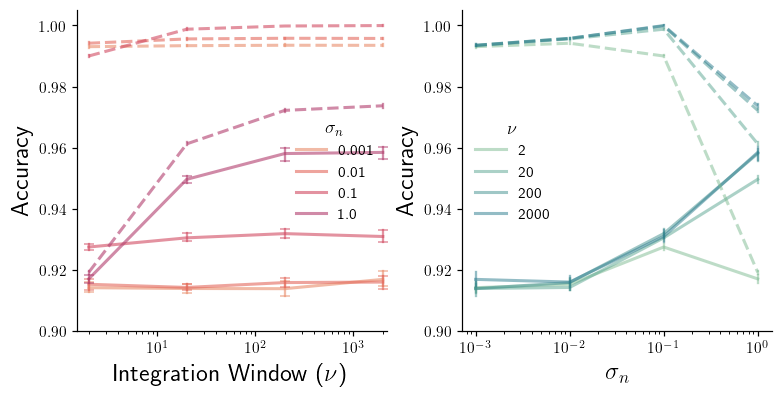

In [ ]:
fig, ax = plt.subplots(2, 2, dpi=110, figsize=(7, 7), layout="constrained")

palettes = ["flare", "crest", "colorblind", "Grays"]
pal_idx = 0

flare_pal = sns.color_palette("flare")
crest_pal = sns.color_palette("crest")

# TODO: top gauss || left accuracy vs nu || right: accuracy vs std 
# TODO: bottom: logistic || left accuracy vs nu || right: accuracy vs std 

#NOTE: Boilerplate code in the comments
# sns.lineplot(data=df_gauss, x="nu", y="best_eval_acc", hue="std", lw=2, err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0], err_kws={"capsize": 3})
# sns.lineplot(data=df, x="nu", y="best_train_acc", hue="std", lw=2, ls="--", err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0], legend=False)

# ax[0].set_xscale("log", base=10)
# ax[0].set_ylim(0.90, 1.005)
# ax[0].set_xlim(1.5, 2200)

# ax[0].set_ylabel(r"Accuracy", fontsize=16)
# ax[0].set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
# ax[0].legend(frameon=False, title=r"$\sigma_n$", title_fontsize=12, fontsize=10)

# # right: std vs accuracy
# sns.lineplot(data=df, x="std", y="best_eval_acc", hue="nu", lw=2, err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[1])
# sns.lineplot(data=df, x="std", y="best_train_acc", hue="nu", lw=2, ls="--", err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[1], legend=False)

# ax[1].set_xscale("log", base=10)
# ax[1].set_ylim(0.90, 1.005)
# # ax[1].set_xlim(1.5, 2200)

# ax[1].set_ylabel(r"Accuracy", fontsize=16)
# ax[1].set_xlabel(r"$\sigma_n$", fontsize=16)
# ax[1].legend(frameon=False, title=r"$\nu$", title_fontsize=12, fontsize=10)
# sns.despine()

/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_30265/1717230367.py:13: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df_gauss, x="nu", y="best_eval_acc", hue="std", lw=2,
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_30265/1717230367.py:16: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df_gauss, x="nu", y="best_train_acc", hue="std", lw=2, ls="--",
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_30265/1717230367.py:28: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df_gauss, x="std", y="best_eval_acc", hue="nu", lw=2,
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_30265/1717230367.py:30: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=df_gauss, x="std", y="best_train_acc", h

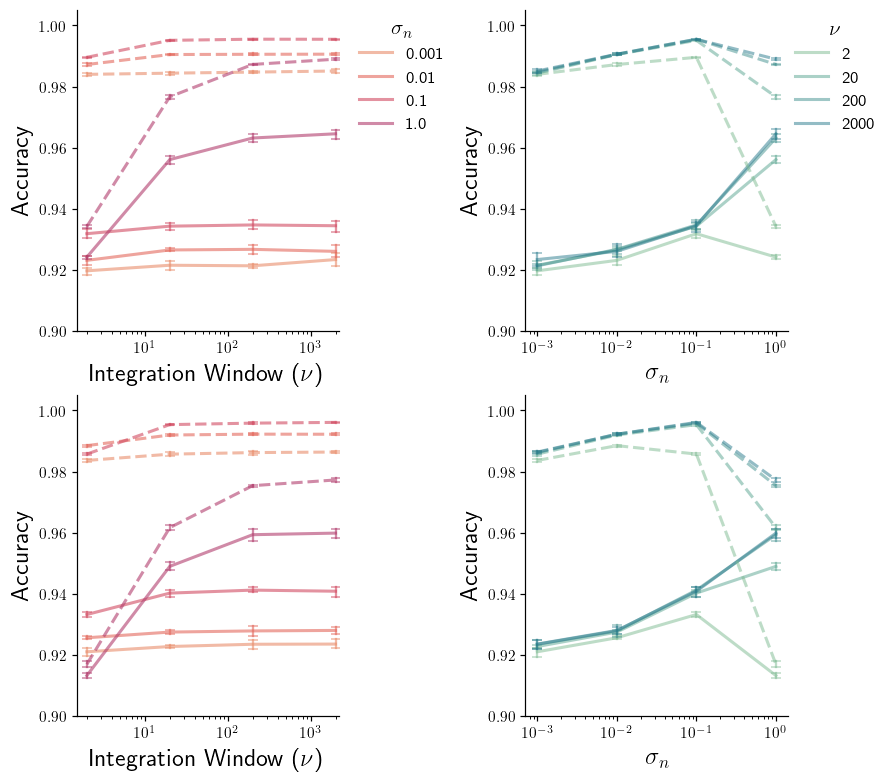

In [ ]:
fig, ax = plt.subplots(2, 2, dpi=110, figsize=(8, 7), layout="constrained")

palettes = ["flare", "crest", "colorblind", "Grays"]
pal_idx = 0

flare_pal = sns.color_palette(palettes[0])
crest_pal = sns.color_palette(palettes[1])
colorblind_pal = sns.color_palette(palettes[2])
grays_pal = sns.color_palette(palettes[3])

# ---- top row: gauss -------------------------------------------------
# left: accuracy vs nu (hue = std)
sns.lineplot(data=df_gauss, x="nu", y="best_eval_acc", hue="std", lw=2,
             err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0,0],
             err_kws={"capsize": 3})
sns.lineplot(data=df_gauss, x="nu", y="best_train_acc", hue="std", lw=2, ls="--",
             err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[0,0], err_kws={"capsize": 3},
             legend=False)

ax[0,0].set_xscale("log", base=10)
ax[0,0].set_ylim(0.90, 1.005)
ax[0,0].set_xlim(1.5, 2200)
ax[0,0].set_ylabel(r"Accuracy", fontsize=16)
ax[0,0].set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax[0,0].legend(frameon=False, title=r"$\sigma_n$", title_fontsize=14, fontsize=11, loc=(1.05, 0.6))

# right: accuracy vs std (hue = nu)
sns.lineplot(data=df_gauss, x="std", y="best_eval_acc", hue="nu", lw=2,
             err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[0,1], err_kws={"capsize": 3})
sns.lineplot(data=df_gauss, x="std", y="best_train_acc", hue="nu", lw=2, ls="--",
             err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[0,1],
             legend=False, err_kws={"capsize": 3})

ax[0,1].set_xscale("log", base=10)
ax[0,1].set_ylim(0.90, 1.005)
# ax[0,1].set_xlim(1.5, 2200)
ax[0,1].set_ylabel(r"Accuracy", fontsize=16)
ax[0,1].set_xlabel(r"$\sigma_n$", fontsize=16)
ax[0,1].legend(frameon=False, title=r"$\nu$", title_fontsize=14, fontsize=11, loc=(1, 0.6))

# ---- bottom row: logistic --------------------------------------------
# left: accuracy vs nu (hue = std)
sns.lineplot(data=df_log, x="nu", y="best_eval_acc", hue="std", lw=2,
             err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[1,0],
             err_kws={"capsize": 3})
sns.lineplot(data=df_log, x="nu", y="best_train_acc", hue="std", lw=2, ls="--",
             err_style="bars", alpha=0.6, palette=flare_pal, ax=ax[1,0],
             legend=False, err_kws={"capsize": 3})

ax[1,0].set_xscale("log", base=10)
ax[1,0].set_ylim(0.90, 1.005)
ax[1,0].set_xlim(1.5, 2200)
ax[1,0].set_ylabel(r"Accuracy", fontsize=16)
ax[1,0].set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
# ax[1,0].legend(frameon=False, title=r"$\sigma_n$", title_fontsize=12, fontsize=10)
ax[1,0].get_legend().set_visible(False)

# right: accuracy vs std (hue = nu)
sns.lineplot(data=df_log, x="std", y="best_eval_acc", hue="nu", lw=2,
             err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[1,1], err_kws={"capsize": 3})
sns.lineplot(data=df_log, x="std", y="best_train_acc", hue="nu", lw=2, ls="--",
             err_style="bars", alpha=0.5, palette=crest_pal, ax=ax[1,1],
             legend=False, err_kws={"capsize": 3})

ax[1,1].set_xscale("log", base=10)
ax[1,1].set_ylim(0.90, 1.005)
# ax[1,1].set_xlim(1.5, 2200)
ax[1,1].set_ylabel(r"Accuracy", fontsize=16)
ax[1,1].set_xlabel(r"$\sigma_n$", fontsize=16)
ax[1,1].legend(frameon=False, title=r"$\nu$", title_fontsize=12, fontsize=10)
ax[1,1].get_legend().set_visible(False)

sns.despine()

today = date.today().isoformat()
# fig.savefig(os.path.join(FIGURES_PATH, f"nu_std_sweep_synth_top_g_bottom_log_{today}.pdf"), dpi=300, transparent=True, bbox_inches="tight")